<a href="https://colab.research.google.com/github/jyothijoo197-ui/Fraud-Detection-Analytics/blob/main/Fraud_Detection_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [2]:
df = pd.read_csv("/content/fraud_detection_dataset.csv")

In [3]:
df

,Time,Amount,Feature1,Feature2,Feature3,Class
0,15795,30381.69,0.193331,1.497369,-1.577702,0
1,860,12225.21,-0.096273,-0.504552,0.471144,1
2,76820,24917.40,0.365301,-1.748382,-0.323920,0
3,54886,16524.12,1.402072,0.133094,1.329997,0
4,6265,46685.25,-1.993931,-0.324773,0.679512,0
...,...,...,...,...,...,...
995,81449,19051.67,-0.464221,0.786293,-1.635989,0
996,60004,17322.63,0.253861,1.348148,0.223424,0
997,62981,11960.38,1.568934,-0.764945,-0.370114,0
998,84659,25491.12,-0.353495,-0.789142,-0.556929,0


In [4]:
df.head()

,Time,Amount,Feature1,Feature2,Feature3,Class
0,15795,30381.69,0.193331,1.497369,-1.577702,0
1,860,12225.21,-0.096273,-0.504552,0.471144,1
2,76820,24917.40,0.365301,-1.748382,-0.323920,0
3,54886,16524.12,1.402072,0.133094,1.329997,0
4,6265,46685.25,-1.993931,-0.324773,0.679512,0


In [5]:
df.tail()

,Time,Amount,Feature1,Feature2,Feature3,Class
995,81449,19051.67,-0.464221,0.786293,-1.635989,0
996,60004,17322.63,0.253861,1.348148,0.223424,0
997,62981,11960.38,1.568934,-0.764945,-0.370114,0
998,84659,25491.12,-0.353495,-0.789142,-0.556929,0
999,54553,41266.05,-1.038169,0.345613,-0.660032,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time      1000 non-null   int64  
 1   Amount    1000 non-null   float64
 2   Feature1  1000 non-null   float64
 3   Feature2  1000 non-null   float64
 4   Feature3  1000 non-null   float64
 5   Class     1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Time      1000 non-null   int64  
 1   Amount    1000 non-null   float64
 2   Feature1  1000 non-null   float64
 3   Feature2  1000 non-null   float64
 4   Feature3  1000 non-null   float64
 5   Class     1000 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 47.0 KB
None


In [8]:
df.describe()

,Time,Amount,Feature1,Feature2,Feature3,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49402.992000,25397.746670,0.022355,0.029642,-0.035458,0.033000
std,29089.058729,14205.878609,0.976655,0.997356,0.997180,0.178726
min,55.000000,21.870000,-3.351611,-3.386814,-3.339500,0.000000
25%,23561.500000,12952.862500,-0.648221,-0.641775,-0.741810,0.000000
50%,50339.500000,26129.780000,0.045187,0.020720,-0.026047,0.000000
75%,73807.250000,37477.340000,0.688067,0.734805,0.679011,0.000000
max,99835.000000,49967.680000,3.495878,2.562528,2.920753,1.000000


In [9]:
print(df.describe())

               Time        Amount     Feature1     Feature2     Feature3  \
count   1000.000000   1000.000000  1000.000000  1000.000000  1000.000000   
mean   49402.992000  25397.746670     0.022355     0.029642    -0.035458   
std    29089.058729  14205.878609     0.976655     0.997356     0.997180   
min       55.000000     21.870000    -3.351611    -3.386814    -3.339500   
25%    23561.500000  12952.862500    -0.648221    -0.641775    -0.741810   
50%    50339.500000  26129.780000     0.045187     0.020720    -0.026047   
75%    73807.250000  37477.340000     0.688067     0.734805     0.679011   
max    99835.000000  49967.680000     3.495878     2.562528     2.920753   

             Class  
count  1000.000000  
mean      0.033000  
std       0.178726  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


In [10]:
df["Class"].value_counts()

,count
Class,
0,967
1,33


In [11]:
print(df["Class"].value_counts())

Class
0    967
1     33
Name: count, dtype: int64


<Axes: xlabel='Class', ylabel='count'>

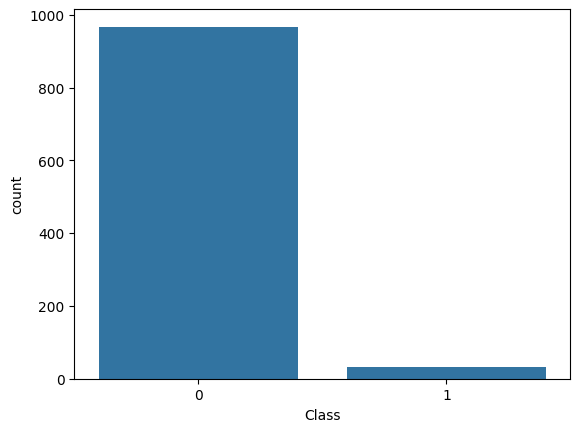

In [12]:
sns.countplot(x="Class", data=df)

Text(0.5, 1.0, 'Fraud Detection')

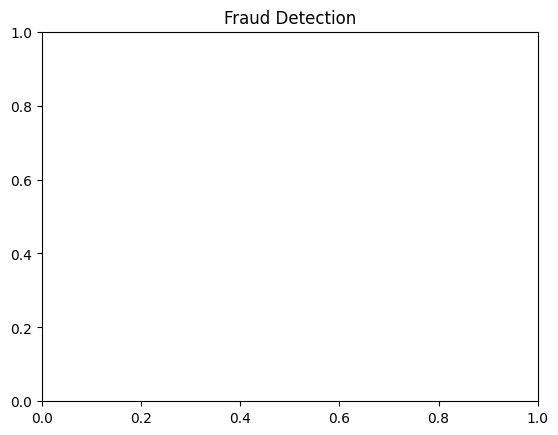

In [13]:
plt.title("Fraud Detection")

Text(0.5, 1.0, 'Fraud vs Normal Transactions')

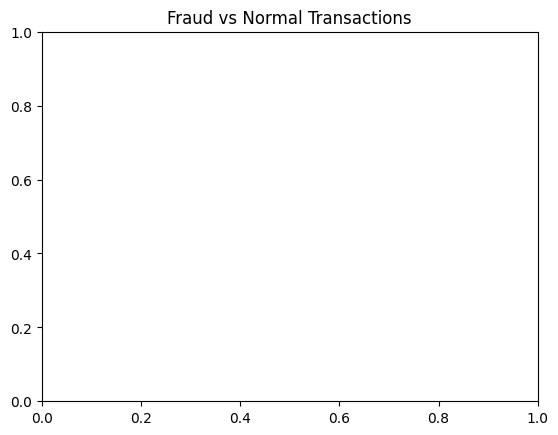

In [14]:
plt.title("Fraud vs Normal Transactions")

In [15]:
plt.show()

<Axes: xlabel='Amount', ylabel='Count'>

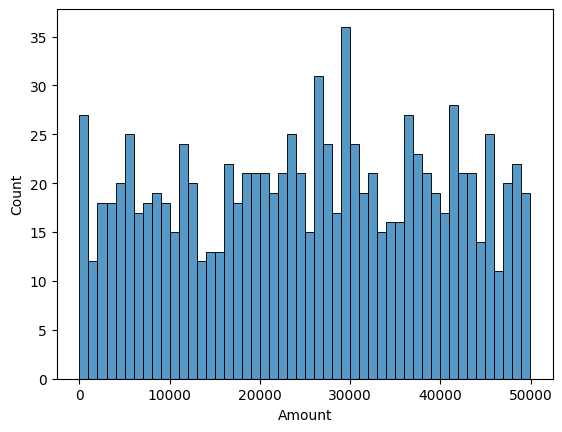

In [16]:
sns.histplot(df["Amount"], bins=50)

Text(0.5, 1.0, 'Transaction Amount Distribution')

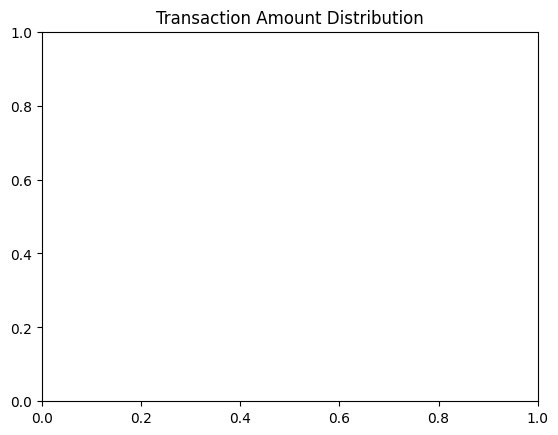

In [17]:
plt.title("Transaction Amount Distribution")

In [18]:
plt.show()

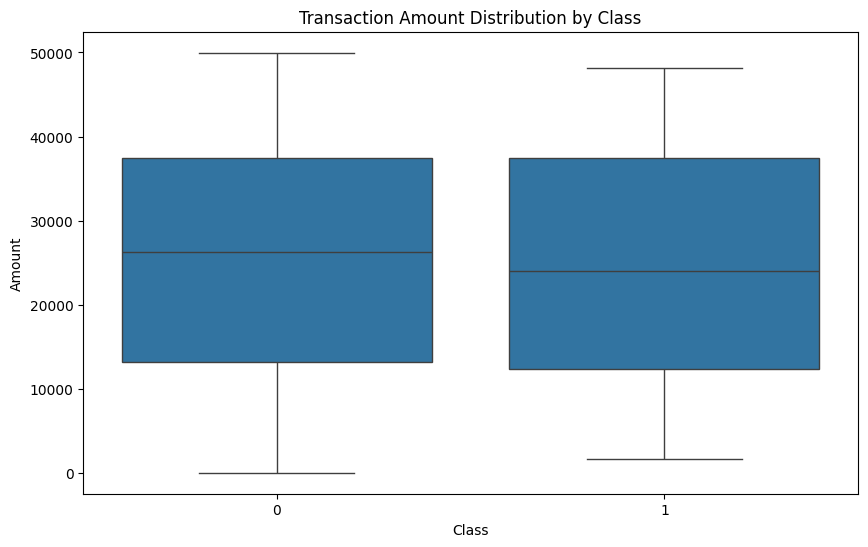

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount Distribution by Class")
plt.show()

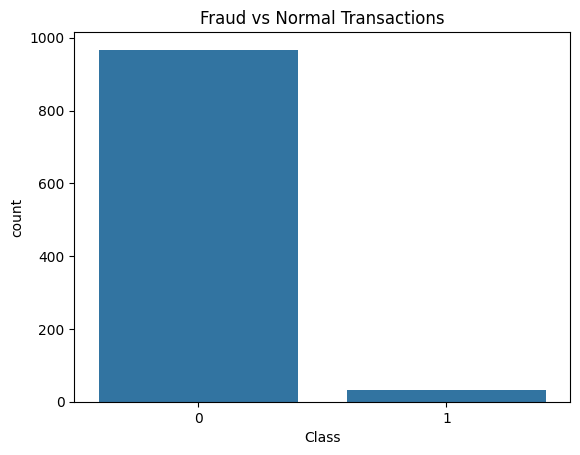

In [20]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

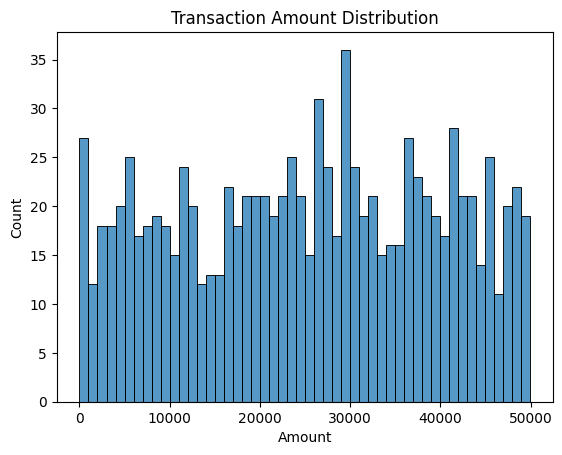

In [21]:
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

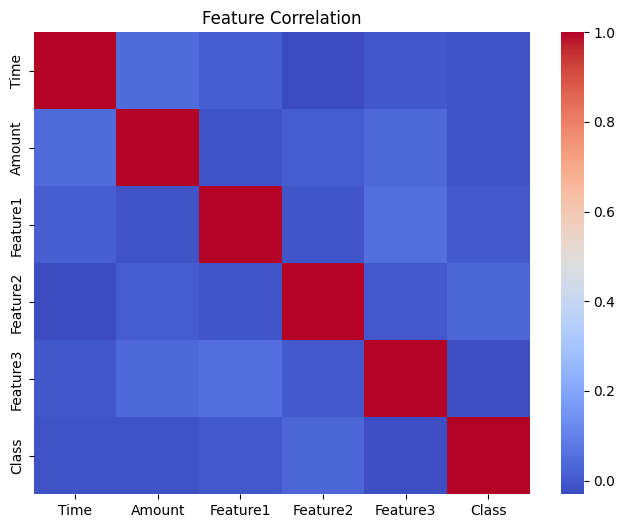

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [24]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred = model.predict(X_test)

In [28]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[193   0]
 [  7   0]]


In [29]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       193
           1       0.00      0.00      0.00         7

    accuracy                           0.96       200
   macro avg       0.48      0.50      0.49       200
weighted avg       0.93      0.96      0.95       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
y_prob = model.predict_proba(X_test)[:,1]

In [31]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.5680977054034049


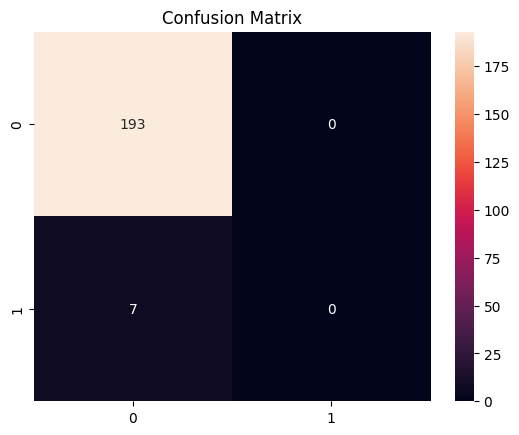

In [32]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()